# PyTorch: Classification using FastAI

In [38]:
import matplotlib.pyplot as plt
from PIL import Image

In [39]:
import torch
import torch.nn.functional as F

In [40]:
from fastai.vision.all import *

# Prepare Dataset

In [41]:
path = untar_data(URLs.MNIST_SAMPLE)

In [42]:
threes = sorted((path/"train"/"3").iterdir())
sevens = sorted((path/"train"/"7").iterdir())
stacked_threes = torch.stack([tensor(Image.open(o)) for o in threes]).float() / 255.0
stacked_sevens = torch.stack([tensor(Image.open(o)) for o in sevens]).float() / 255.0

In [43]:
val_threes = sorted((path/"valid"/"3").iterdir())
val_sevens = sorted((path/"valid"/"7").iterdir())
val_stacked_threes = torch.stack([tensor(Image.open(o)) for o in val_threes]).float() / 255.0
val_stacked_sevens = torch.stack([tensor(Image.open(o)) for o in val_sevens]).float() / 255.0

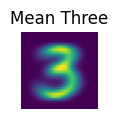

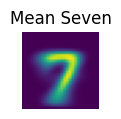

In [44]:
threes_mean = stacked_threes.mean(0)
sevens_mean = stacked_sevens.mean(0)
_ = show_image(threes_mean, title="Mean Three")
_ = show_image(sevens_mean, title="Mean Seven")

In [45]:
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
print(f"Train.X.shape: {train_x.shape}")
print(f"Train.Y.shape: {train_y.shape}")

Train.X.shape: torch.Size([12396, 784])
Train.Y.shape: torch.Size([12396, 1])


In [46]:
val_x = torch.cat([val_stacked_threes, val_stacked_sevens]).view(-1, 28*28)
val_y = tensor([1]*len(val_threes) + [0]*len(val_sevens)).unsqueeze(1)
print(f"Valid.X.shape: {val_x.shape}")
print(f"Valid.Y.shape: {val_y.shape}")

Valid.X.shape: torch.Size([2038, 784])
Valid.Y.shape: torch.Size([2038, 1])


In [47]:
train_ds = list(zip(train_x, train_y))
x, y = next(iter(train_ds))
print(f"TrainItem.X: {x.shape}")
print(f"TrainItem.Y: {y}")

TrainItem.X: torch.Size([784])
TrainItem.Y: tensor([1])


In [48]:
val_ds = list(zip(val_x, val_y))
x, y = next(iter(val_ds))
print(f"ValidItem.X: {x.shape}")
print(f"ValidItem.Y: {y}")

ValidItem.X: torch.Size([784])
ValidItem.Y: tensor([1])


In [49]:
dl = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_dl = DataLoader(val_ds, batch_size=32, shuffle=True)

In [50]:
dls = DataLoaders(dl, valid_dl)

# Train Model

In [51]:
# Basic optimizer class
class BasicOptim:
    def __init__(self,params,lr):
        self.params,self.lr = list(params),lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

In [52]:
# Define loss function
def mnist_loss(y_hat, y):
    y_hat = F.sigmoid(y_hat)
    return torch.where(y == 1, 1-y_hat, y_hat).mean()

In [53]:
# Define accuracy function
def mnist_accuracy(y_hat, y, threshold=0.5):
    y_hat = F.sigmoid(y_hat)
    correct = (y_hat > threshold) == y
    return correct.float().mean()

In [54]:
# Define gradients calculation function
def calc_grad(xb, yb, model):
    yb_hat = model(xb)
    loss = mnist_loss(yb_hat, yb)
    loss.backward()

In [55]:
# Define function to calculate one training epoch
def train_epoch(model, optimizer):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        optimizer.step()
        optimizer.zero_grad()

In [56]:
# Define function to calculate one validation epoch
def validate_epoch(model):
    accs = [mnist_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [57]:
def train_model(model, optimizer, epochs):
    for i in range(epochs):
        train_epoch(model, optimizer)
        print(validate_epoch(model), end=' ')

In [58]:
# Simple model with two linear layers and one non-linear ReLU layer
model = torch.nn.Sequential(
    torch.nn.Linear(28*28, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 1),
)

# Create optimizer
optimizer = BasicOptim(model.parameters(), lr=1e-3)

# Train model
train_model(model, optimizer, 20)

0.9058 0.9619 0.9656 0.9668 0.9668 0.9658 0.9651 0.9653 0.9653 0.9646 0.9653 0.9653 0.9651 0.9649 0.9654 0.9666 0.9664 0.9676 0.9678 0.9673 